# 1D CNN Model Training - Customer Review Classification

This notebook implements and trains the 1D Convolutional Neural Network (CNN) model for the customer review classification project.

The model uses the shared preprocessed hotel review dataset and classifies each review into one of three classes:

- **0 - Poor**
- **1 - Average**
- **2 - Good**

The same processed training, validation, and test datasets are used across all team models to maintain a fair comparison.

In [3]:
# Libraries used for loading data and handling file paths
import os
import sys
import pickle
import numpy as np

# TensorFlow is used to build and train the deep learning model
import tensorflow as tf

# Set random seeds to make the experiment more reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully.")

TensorFlow version: 2.21.0
Setup completed successfully.


## Load Processed Training Data

The CNN uses the same preprocessed data prepared for all four deep learning models.

During model development, only the **training set** and **validation set** are used. The test set remains untouched until the final evaluation to avoid data leakage and maintain a fair model comparison.

In [4]:
# Path to the shared processed dataset
DATA_PATH = "../../data/processed"

# Load the padded training and validation sequences
X_train = np.load(os.path.join(DATA_PATH, "X_train_pad.npy"))
X_val = np.load(os.path.join(DATA_PATH, "X_val_pad.npy"))

# Load the corresponding class labels
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))
y_val = np.load(os.path.join(DATA_PATH, "y_val.npy"))

# Load the shared class weights calculated from the training data
with open(os.path.join(DATA_PATH, "class_weights.pkl"), "rb") as file:
    class_weights = pickle.load(file)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation data shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)
print("Class weights:", class_weights)

Training data shape: (4895, 200)
Training labels shape: (4895,)
Validation data shape: (1049, 200)
Validation labels shape: (1049,)
Class weights: {np.int64(0): np.float64(1.8776371308016877), np.int64(1): np.float64(1.317985998922994), np.int64(2): np.float64(0.585246293639407)}


## Build the 1D CNN Model

The CNN architecture is defined separately in `cnn_model.py`. This keeps the model structure reusable and separates the model definition from the training process.

The initial CNN configuration follows the common project settings used for fair model comparison.

In [5]:
# Import the CNN architecture defined in cnn_model.py
from cnn_model import build_cnn_model

# Build the CNN using the initial project settings
model = build_cnn_model(
    vocab_size=10000,
    sequence_length=200,
    embedding_dim=128,
    num_filters=64,
    kernel_size=5,
    dropout_rate=0.5,
    num_classes=3,
)

# Build the model for input sequences with a length of 200
model.build(input_shape=(None, 200))

# Display the CNN architecture and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,219 (5.04 MB)

 Trainable params: 1,321,219 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Initial CNN Model

The CNN is trained using the shared training set and class weights.

The validation set is used to monitor how well the model generalizes to unseen data during training. The test set is not used at this stage.

For the initial experiment, the model is trained for **10 epochs** with a **batch size of 32**, following the common project settings.

In [6]:
# Initial training settings shared across the project
EPOCHS = 10
BATCH_SIZE = 32

# Train the CNN using the training data and monitor validation performance
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5575 - loss: 0.9887 - val_accuracy: 0.6654 - val_loss: 0.8245
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6774 - loss: 0.7642 - val_accuracy: 0.7026 - val_loss: 0.6853
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7412 - loss: 0.6117 - val_accuracy: 0.7169 - val_loss: 0.6156
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7796 - loss: 0.5153 - val_accuracy: 0.7235 - val_loss: 0.6113
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8047 - loss: 0.4491 - val_accuracy: 0.7274 - val_loss: 0.6033
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8210 - loss: 0.4024 - val_accuracy: 0.7388 - val_loss: 0.6074
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8306 - loss: 0.3712 - val_accuracy: 0.7417 - val_loss: 0.6283
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8437 - loss: 0.3350 - val_acc

## Training and Validation Learning Curves

The learning curves are used to compare the CNN's training and validation performance across epochs. This helps identify convergence and possible overfitting.

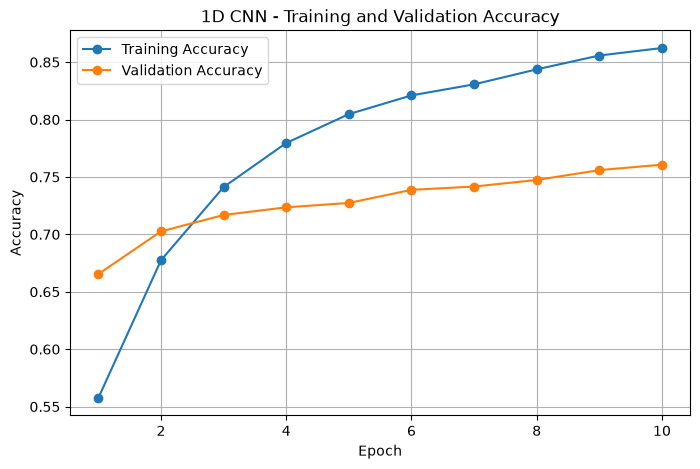

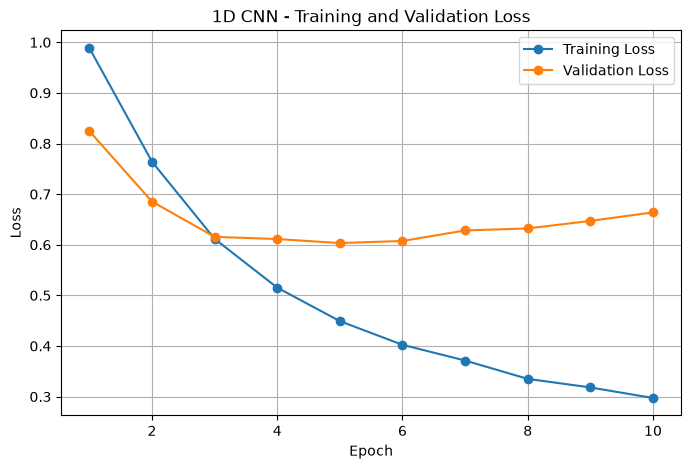

In [7]:
import matplotlib.pyplot as plt

# Get the training results recorded after each epoch
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Initial Training Analysis

The 1D CNN showed consistent learning across the 10 training epochs. Training accuracy increased from approximately **55.75% to 86.23%**, while validation accuracy improved from approximately **66.54% to 76.07%**.

Training loss continuously decreased from **0.9887 to 0.2973**, showing that the model was learning the training data effectively. Validation loss initially decreased and reached its lowest value of approximately **0.6033 at epoch 5**. After this point, validation loss gradually increased and reached **0.6639 at epoch 10**, while training loss continued to decrease.

This divergence between training and validation loss indicates that the model begins to show signs of **overfitting after approximately epoch 5**. However, validation accuracy continued to improve throughout the 10 epochs. Therefore, the initial experiment provides useful evidence for later evaluation and possible model tuning.

## CNN Training with Early Stopping

The initial 10-epoch experiment showed that training loss continued to decrease while validation loss began increasing after approximately epoch 5, indicating signs of overfitting.

To control overfitting, a second training experiment is performed using **Early Stopping**. The CNN architecture and shared dataset remain unchanged. Training is stopped when validation loss no longer improves, and the model weights from the best validation-loss epoch are restored.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Build a fresh CNN so this experiment starts with new model weights
tuned_model = build_cnn_model(
    vocab_size=10000,
    sequence_length=200,
    embedding_dim=128,
    num_filters=64,
    kernel_size=5,
    dropout_rate=0.5,
    num_classes=3,
)

# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

# Allow additional epochs, while EarlyStopping decides when to stop
TUNING_EPOCHS = 15

tuned_history = tuned_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=TUNING_EPOCHS,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5467 - loss: 0.9994 - val_accuracy: 0.6673 - val_loss: 0.8364
Epoch 2/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6917 - loss: 0.7446 - val_accuracy: 0.7140 - val_loss: 0.6730
Epoch 3/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7544 - loss: 0.6021 - val_accuracy: 0.7312 - val_loss: 0.6242
Epoch 4/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7920 - loss: 0.5116 - val_accuracy: 0.7369 - val_loss: 0.5963
Epoch 5/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8145 - loss: 0.4396 - val_accuracy: 0.7426 - val_loss: 0.5919
Epoch 6/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8347 - loss: 0.3869 - val_accuracy: 0.7293 - val_loss: 0.6048
Epoch 7/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8460 - loss: 0.3584 - val_accuracy: 0.7407 - val_loss: 0.6238
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.


### Early Stopping Experiment Analysis

Early Stopping terminated training after epoch 7 because validation loss did not improve for two consecutive epochs.

The lowest validation loss was **0.5919 at epoch 5**, with a validation accuracy of approximately **74.26%**. After epoch 5, training loss continued to decrease while validation loss increased to **0.6048** and **0.6238**, providing further evidence of overfitting.

Because `restore_best_weights=True` was used, the model weights from epoch 5 were automatically restored. This allows the final model state to represent the point with the lowest observed validation loss rather than the later overfitted epochs.

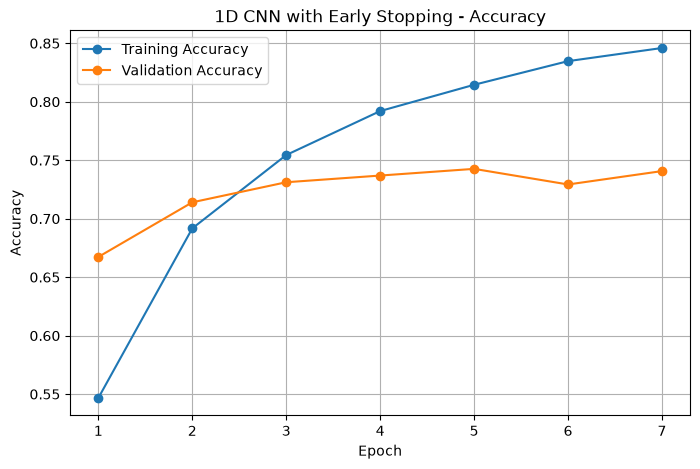

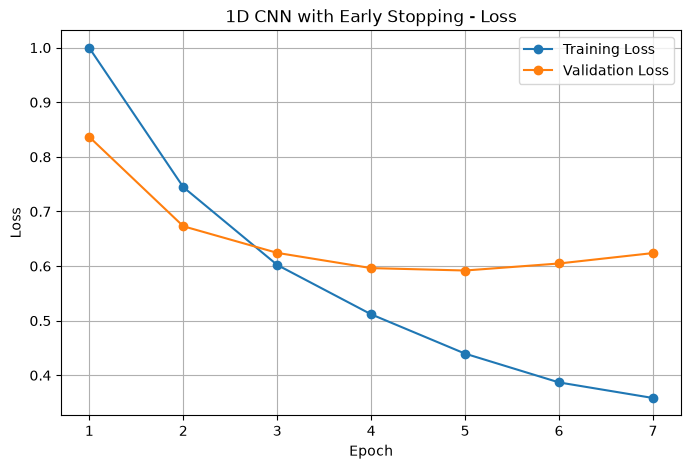

In [9]:
# Get the training history from the Early Stopping experiment
tuned_train_accuracy = tuned_history.history["accuracy"]
tuned_val_accuracy = tuned_history.history["val_accuracy"]
tuned_train_loss = tuned_history.history["loss"]
tuned_val_loss = tuned_history.history["val_loss"]

tuned_epochs = range(1, len(tuned_train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(tuned_epochs, tuned_train_accuracy, marker="o", label="Training Accuracy")
plt.plot(tuned_epochs, tuned_val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN with Early Stopping - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(tuned_epochs, tuned_train_loss, marker="o", label="Training Loss")
plt.plot(tuned_epochs, tuned_val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN with Early Stopping - Loss")
plt.legend()
plt.grid(True)
plt.show()

### Final CNN Configuration Selection

Based on the validation results, the CNN trained with Early Stopping is selected as the final CNN configuration.

The model architecture remains unchanged from the initial experiment:

- Vocabulary size: **10,000**
- Sequence length: **200**
- Embedding dimension: **128**
- Conv1D filters: **64**
- Kernel size: **5**
- MaxPooling1D followed by GlobalMaxPooling1D
- Dropout rate: **0.5**
- Output classes: **3**
- Optimizer: **Adam**
- Loss function: **Sparse Categorical Crossentropy**
- Batch size: **32**
- Class weighting: **Enabled using the shared training-set class weights**

Early Stopping monitors validation loss with a patience of 2 epochs and restores the weights from the epoch with the lowest validation loss.

In this experiment, training stopped after epoch 7 and restored the model weights from **epoch 5**, where the lowest validation loss of approximately **0.5919** was observed.

This configuration is selected before evaluating the untouched test set.

## Final Evaluation on the Test Set

After completing model development and selecting the final CNN configuration using only the training and validation sets, the untouched test set is now used for final evaluation.

The test set is used only at this final stage to provide an unbiased estimate of the CNN's generalization performance.

In [10]:
# Load the untouched test dataset for final evaluation
X_test = np.load(os.path.join(DATA_PATH, "X_test_pad.npy"))
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test data shape: (1050, 200)
Test labels shape: (1050,)


### Test Set Performance Metrics

The final CNN is evaluated on the untouched test set using the common classification metrics defined for the project.

The reported metrics include accuracy, macro-averaged precision, recall, F1-score, and multiclass ROC-AUC. Macro averaging gives equal importance to each of the three review classes despite the class imbalance.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.preprocessing import label_binarize

# Generate probability predictions for the untouched test set
y_prob = tuned_model.predict(X_test, verbose=1)

# Select the class with the highest predicted probability
y_pred = np.argmax(y_prob, axis=1)

# Calculate the main classification metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)
test_recall = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)
test_f1 = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

# Convert the true labels to one-hot format for multiclass ROC-AUC
y_test_binary = label_binarize(y_test, classes=[0, 1, 2])

# Calculate macro-averaged multiclass ROC-AUC using One-vs-Rest
test_roc_auc = roc_auc_score(
    y_test_binary,
    y_prob,
    average="macro",
    multi_class="ovr",
)

print(f"Test Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision:      {test_precision:.4f}")
print(f"Macro Recall:         {test_recall:.4f}")
print(f"Macro F1-Score:       {test_f1:.4f}")
print(f"Macro ROC-AUC (OvR):  {test_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Poor", "Average", "Good"],
        digits=4,
        zero_division=0,
    )
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Test Accuracy:        0.7590
Macro Precision:      0.7172
Macro Recall:         0.7663
Macro F1-Score:       0.7323
Macro ROC-AUC (OvR):  0.9037

Classification Report:
              precision    recall  f1-score   support

        Poor     0.6190    0.8387    0.7123       186
     Average     0.6039    0.6992    0.6481       266
        Good     0.9286    0.7609    0.8364       598

    accuracy                         0.7590      1050
   macro avg     0.7172    0.7663    0.7323      1050
weighted avg     0.7915    0.7590    0.7667      1050



### Confusion Matrix

The confusion matrix shows how the final CNN predictions are distributed across the three review classes: Poor, Average, and Good.

It helps identify which classes are classified correctly and which classes are commonly confused with each other.

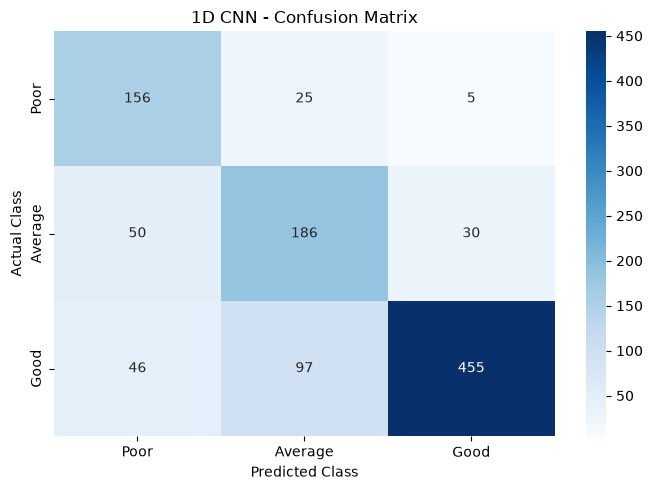

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the confusion matrix using the final test predictions
cm = confusion_matrix(y_test, y_pred)

class_names = ["Poor", "Average", "Good"]

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("1D CNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### ROC Curves and AUC

ROC curves are used to evaluate the CNN's ability to distinguish each review class from the other classes.

For this multiclass problem, the One-vs-Rest (OvR) approach is used to calculate an ROC curve and AUC score for each class.

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


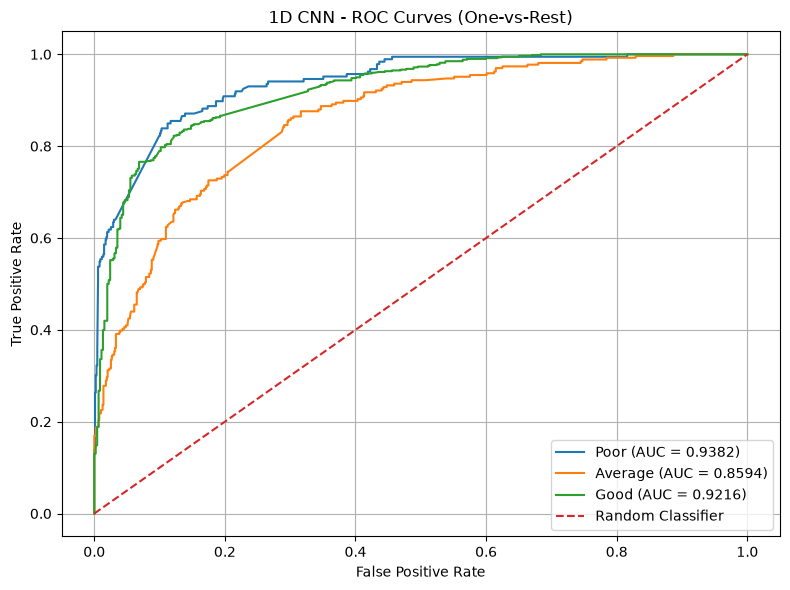

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities for each test review
y_pred_prob = model.predict(X_test)

# Convert the test labels into one-hot format for multiclass ROC analysis
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

class_names = ["Poor", "Average", "Good"]

plt.figure(figsize=(8, 6))

# Calculate and plot one ROC curve for each class
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

# Diagonal line represents random classification
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("1D CNN - ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Final CNN Evaluation Summary

The final 1D CNN achieved a test accuracy of **75.90%**, with a macro precision of **71.72%**, macro recall of **76.63%**, and macro F1-score of **73.23%**. The macro ROC-AUC (One-vs-Rest) was **0.9037**, indicating strong overall class-separation ability.

The class-wise ROC-AUC scores were **0.9382 for Poor**, **0.8594 for Average**, and **0.9216 for Good**. The model therefore showed stronger separation for the Poor and Good classes, while the Average class was comparatively more difficult to distinguish.

The confusion matrix also showed that the model correctly classified **156 of 186 Poor**, **186 of 266 Average**, and **455 of 598 Good** reviews. Most classification difficulty occurred around the Average class, including confusion between Average and the other two classes.

Overall, the results show that the 1D CNN provides good classification performance on the unseen test set, while some class-level errors remain, particularly for the Average category.

In [19]:
# Save the final trained CNN (Convolutional Neural Network) model locally

# DATA_PATH points to <project_root>/data/processed,
# so move up two levels to obtain the project root directory
PROJECT_ROOT = os.path.abspath(os.path.join(DATA_PATH, "..", ".."))

MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, "models_saved")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

final_model_path = os.path.join(MODEL_SAVE_PATH, "cnn_final.keras")

model.save(final_model_path)

print("Final CNN model saved successfully.")
print("Saved to:", final_model_path)

Final CNN model saved successfully.
Saved to: c:\4th Year\Assignment Projects\DL\customer-feedback-classification\models_saved\cnn_final.keras


## Export Final CNN Model Outputs

The final CNN (Convolutional Neural Network) model artifacts are saved in a standardized format for model comparison and integration with the other team models.

The exported outputs include the trained model, final evaluation metrics, confusion matrix, training history, and learning curves.

In [21]:
# Export final CNN (Convolutional Neural Network) outputs
import json

# Create a dedicated folder for the CNN outputs
CNN_OUTPUT_PATH = os.path.join(PROJECT_ROOT, "models_saved", "cnn")
os.makedirs(CNN_OUTPUT_PATH, exist_ok=True)

# 1. Save the trained CNN model
cnn_model_path = os.path.join(CNN_OUTPUT_PATH, "cnn_model.keras")
model.save(cnn_model_path)

# 2. Save final evaluation metrics
cnn_metrics = {
    "accuracy": float(test_accuracy),
    "precision_macro": float(test_precision),
    "recall_macro": float(test_recall),
    "f1_macro": float(test_f1),
    "roc_auc_ovr_macro": float(test_roc_auc),
}

cnn_metrics_path = os.path.join(CNN_OUTPUT_PATH, "cnn_metrics.json")

with open(cnn_metrics_path, "w") as f:
    json.dump(cnn_metrics, f, indent=4)

# 3. Save confusion matrix
cnn_confusion_matrix_path = os.path.join(
    CNN_OUTPUT_PATH,
    "cnn_confusion_matrix.npy"
)
np.save(cnn_confusion_matrix_path, cm)

# 4. Save training history
cnn_history_path = os.path.join(CNN_OUTPUT_PATH, "cnn_history.pkl")

with open(cnn_history_path, "wb") as f:
    pickle.dump(history.history, f)

# 5. Save learning curves as an image
cnn_learning_curves_path = os.path.join(
    CNN_OUTPUT_PATH,
    "cnn_learning_curves.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(cnn_learning_curves_path, dpi=300)
plt.close()

print("CNN outputs exported successfully.")
print("\nOutput directory:", CNN_OUTPUT_PATH)

print("\nGenerated files:")
for filename in sorted(os.listdir(CNN_OUTPUT_PATH)):
    print("-", filename)

CNN outputs exported successfully.

Output directory: c:\4th Year\Assignment Projects\DL\customer-feedback-classification\models_saved\cnn

Generated files:
- cnn_confusion_matrix.npy
- cnn_history.pkl
- cnn_learning_curves.png
- cnn_metrics.json
- cnn_model.keras
